In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from tensordict import TensorDict
import pandas as pd
import torch
from IPython.display import display
from rl4co.utils.trainer import RL4COTrainer

sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.metrics.objective import total_distance
from dvrptw_bench.rl.routefinder_adapter import instance_to_routefinder_td, routefinder_actions_to_solution
from dvrptw_bench.rl.mtvrp_solomon_generator import SolomonMTVRPGenerator
from dvrptw_bench.rl.mtvrp_solomon_generator import MTVRPGenerator
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.common.typing import VRPTWInstance
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator
from routefinder.models import RouteFinderBase, RouteFinderPolicy
from routefinder.utils import evaluate as evaluate_routefinder

In [2]:
DATASET_ROOT = Path('../dataset/solomon_rc100')
RC_DATASET_ROOT = Path('../dataset/solomon_rc100')
C_DATASET_ROOT = Path('../dataset/solomon_c100')
OUTPUT_ROOT = Path('../outputs/notebook_routefinder_solomon_generated')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CUSTOMERS = 10
NUM_EPOCHS = 3
BATCH_SIZE = 256
TRAIN_DATA_SIZE = 1000
VAL_DATA_SIZE = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-6
NUM_AUGMENT = 8
ORTOOLS_TIME_LIMIT_S = .1
MAX_EVAL_INSTANCES = 5  # set to None to evaluate all RC instances
NORMALIZE_COORDS = True # whether to normalize coordinates to [0, 1] when creating RouteFinder training data

if torch.cuda.is_available():
    device = torch.device('cuda')
    accelerator = 'gpu'
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    accelerator = 'mps'
else:
    device = torch.device('cpu')
    accelerator = 'cpu'

print('Device:', device)
print('Dataset root:', DATASET_ROOT.resolve())
print('Output root:', OUTPUT_ROOT.resolve())


Device: mps
Dataset root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/dataset/solomon_rc100
Output root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/outputs/notebook_routefinder_solomon_generated


In [3]:

from dvrptw_bench.rl.env_flexible import MTVRPFlexibleEnv


generator = MTVRPGenerator(num_loc=NUM_CUSTOMERS, max_time=10.11,variant_preset='vrptw')
env = MTVRPFlexibleEnv(generator, check_solution=False)
policy = RouteFinderPolicy(env_name=env.name).to(device)
model = RouteFinderBase(
    env,
    policy,
    batch_size=BATCH_SIZE,
    train_data_size=TRAIN_DATA_SIZE,
    val_data_size=VAL_DATA_SIZE,
    optimizer_kwargs={'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
)

trainer = RL4COTrainer(
    max_epochs=NUM_EPOCHS,
    accelerator=accelerator,
    devices=1,
    logger=None,
    num_sanity_val_steps=0,
    precision='32-true',
)
trainer.fit(model) 
# trainer.save_checkpoint(OUTPUT_ROOT / 'end_of_training.pt')
# model = model.load_from_checkpoint(OUTPUT_ROOT / 'checkpoints/last.ckpt', weights_only=False, map_location=torch.device('cpu'))

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to poten

all


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ MTVRPFlexibleEnv  │      0 │ train │     0 │
│ 1 │ policy   │ RouteFinderPolicy │  1.3 M │ train │     0 │
│ 2 │ baseline │ SharedBaseline    │      0 │ train │     0 │
└───┴──────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 112                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=3` reached.


In [4]:
instance_paths = find_rc_instances(DATASET_ROOT)
assert instance_paths, f'No RC instances found under {DATASET_ROOT.resolve()}'

if MAX_EVAL_INSTANCES is not None:
    instance_paths = instance_paths[:MAX_EVAL_INSTANCES]

instances = [parse_solomon(path, max_customers=NUM_CUSTOMERS) for path in instance_paths]
print('Loaded instances:', [instance.instance_id for instance in instances])


def solve_with_routefinder(instance, num_augment=NUM_AUGMENT):
    t0 = time.perf_counter()
    td = instance_to_routefinder_td(instance, normalize_coords=NORMALIZE_COORDS).to(device)
    td_reset = env.reset(td)
    model.to(device).eval()

    with torch.inference_mode():
        if num_augment > 1:
            out = evaluate_routefinder(model, td_reset.clone(), num_augment=num_augment)
            actions = out.get('best_aug_actions', out.get('best_multistart_actions', out.get('actions')))
        else:
            out = model.policy(
                td_reset.clone(),
                env,
                phase='test',
                decode_type='greedy',
                return_actions=True,
            )
            actions = out['actions']

    solution = routefinder_actions_to_solution(actions, instance, strategy='routefinder')
    solution.total_distance = total_distance(instance, solution)
    solution.solve_time_s = time.perf_counter() - t0
    solution.details.update({'num_augment': num_augment})
    return solution

ortools = ORToolsVRPTWSolver()
routefinder_solutions = {}
ortools_solutions = {}
rows = []

for instance in instances:
    rf_solution = solve_with_routefinder(instance)
    or_solution = ortools.solve(instance, time_limit_s=ORTOOLS_TIME_LIMIT_S)

    routefinder_solutions[instance.instance_id] = rf_solution
    ortools_solutions[instance.instance_id] = or_solution

    gap_pct = 100.0 * (rf_solution.total_distance - or_solution.total_distance) / or_solution.total_distance
    rows.append(
        {
            'instance_id': instance.instance_id,
            'n_customers': instance.n_customers,
            'routefinder_distance': rf_solution.total_distance,
            'ortools_distance': or_solution.total_distance,
            'gap_to_ortools_pct': gap_pct,
            'routefinder_routes': len([r for r in rf_solution.routes if r.node_ids]),
            'ortools_routes': len([r for r in or_solution.routes if r.node_ids]),
            'routefinder_time_s': rf_solution.solve_time_s,
            'ortools_time_s': or_solution.solve_time_s,
        }
    )

results_df = pd.DataFrame(rows).sort_values('gap_to_ortools_pct').reset_index(drop=True)
results_df[['routefinder_distance', 'ortools_distance', 'gap_to_ortools_pct', 'routefinder_time_s', 'ortools_time_s']] = results_df[[
    'routefinder_distance', 'ortools_distance', 'gap_to_ortools_pct', 'routefinder_time_s', 'ortools_time_s'
]].round(3)

display(results_df)
results_df.to_csv(OUTPUT_ROOT / 'routefinder_vs_ortools.csv', index=False)
print('Saved table to', OUTPUT_ROOT / 'routefinder_vs_ortools.csv')


Loaded instances: ['RC201.txt', 'RC202.txt', 'RC203.txt', 'RC204.txt', 'RC205.txt']


,instance_id,n_customers,routefinder_distance,ortools_distance,gap_to_ortools_pct,routefinder_routes,ortools_routes,routefinder_time_s,ortools_time_s
0,RC204.txt,10,148.0,135.0,9.630,1,1,0.069,1.001
1,RC202.txt,10,219.0,164.0,33.537,2,2,0.088,1.001
2,RC203.txt,10,219.0,164.0,33.537,2,2,0.072,1.001
3,RC201.txt,10,267.0,180.0,48.333,2,2,0.256,1.197
4,RC205.txt,10,271.0,166.0,63.253,2,2,0.090,1.001


Saved table to ../outputs/notebook_routefinder_solomon_generated/routefinder_vs_ortools.csv


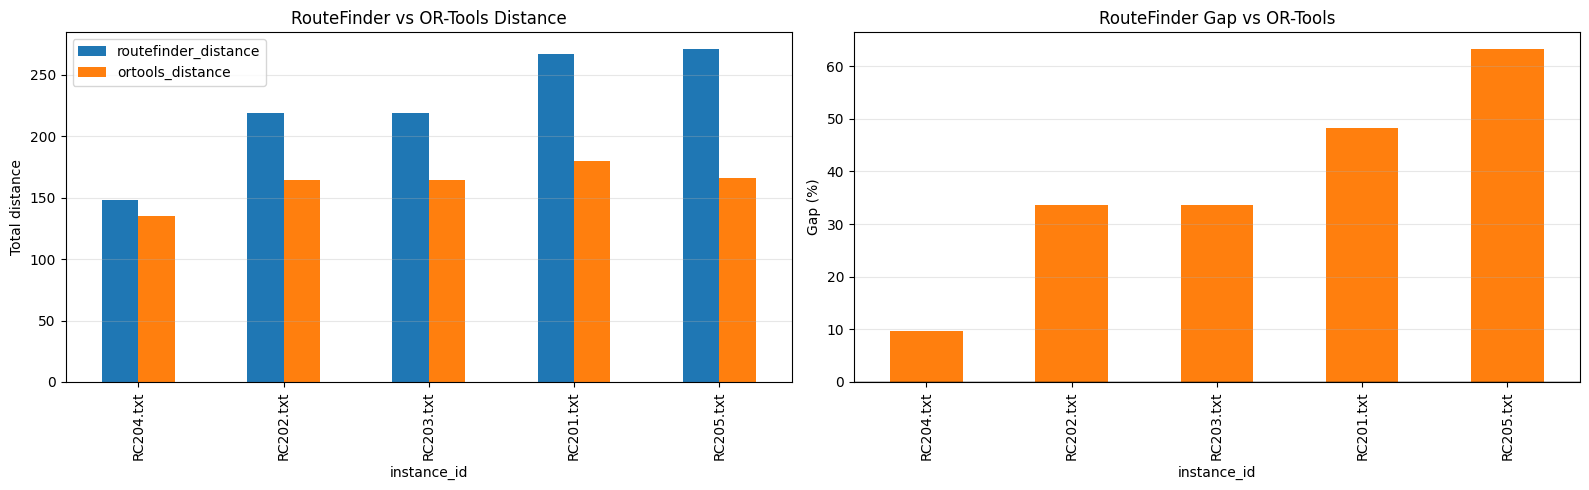

Saved summary plot to ../outputs/notebook_routefinder_solomon_generated/routefinder_vs_ortools_summary.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df = results_df.set_index('instance_id')
plot_df[['routefinder_distance', 'ortools_distance']].plot(kind='bar', ax=axes[0])
axes[0].set_title('RouteFinder vs OR-Tools Distance')
axes[0].set_ylabel('Total distance')
axes[0].grid(axis='y', alpha=0.3)

plot_df['gap_to_ortools_pct'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('RouteFinder Gap vs OR-Tools')
axes[1].set_ylabel('Gap (%)')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'routefinder_vs_ortools_summary.png', dpi=180)
plt.show()
print('Saved summary plot to', OUTPUT_ROOT / 'routefinder_vs_ortools_summary.png')



=== RC201.txt ===
RouteFinder distance: 267.0
OR-Tools distance: 180.0

=== RC202.txt ===
RouteFinder distance: 219.0
OR-Tools distance: 164.0

=== RC203.txt ===
RouteFinder distance: 219.0
OR-Tools distance: 164.0


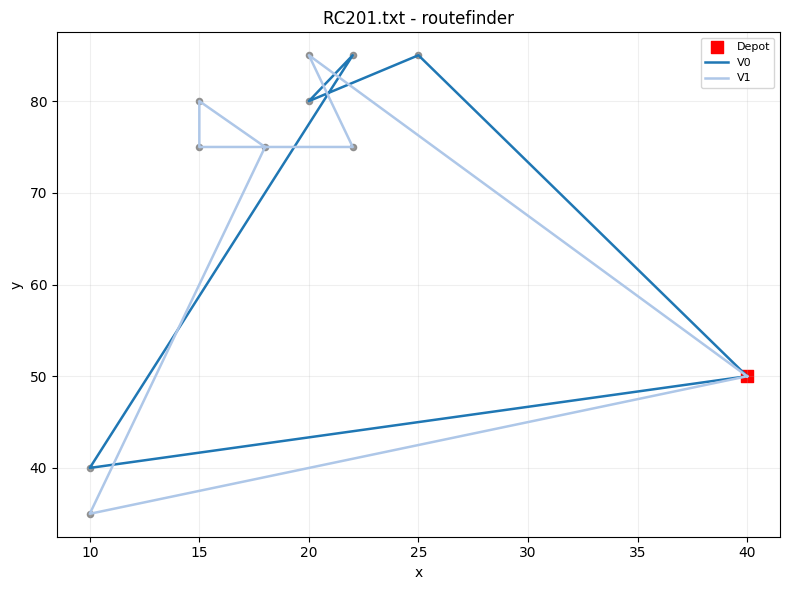

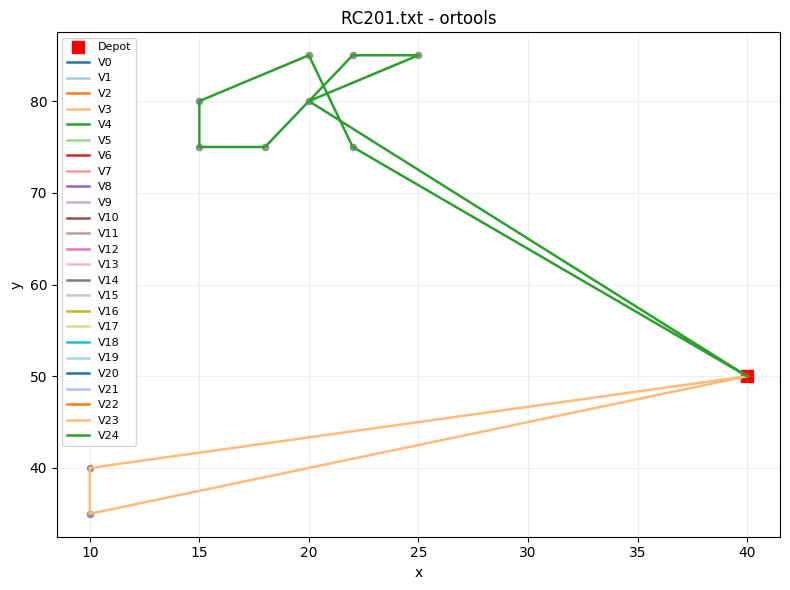

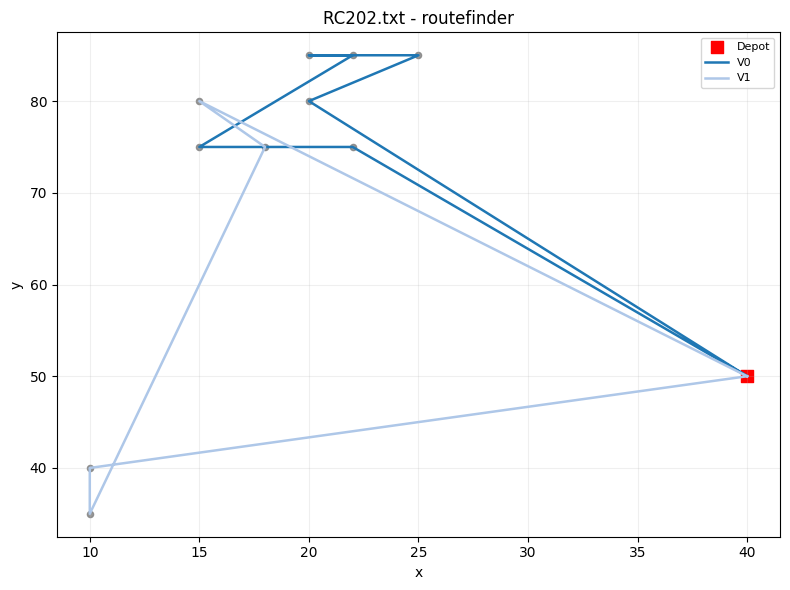

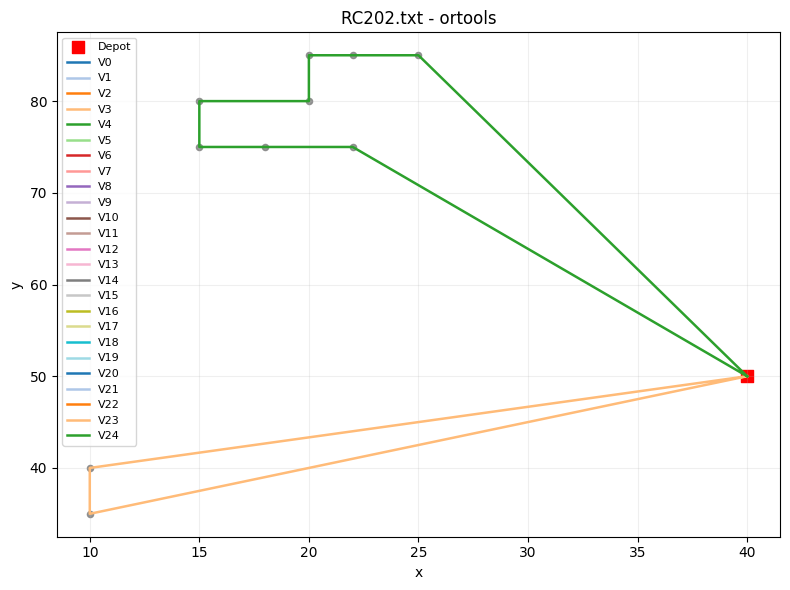

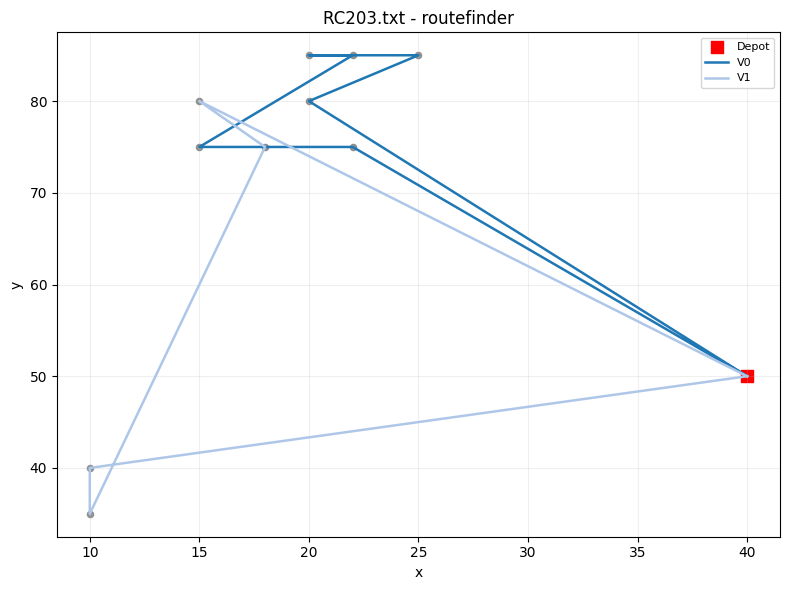

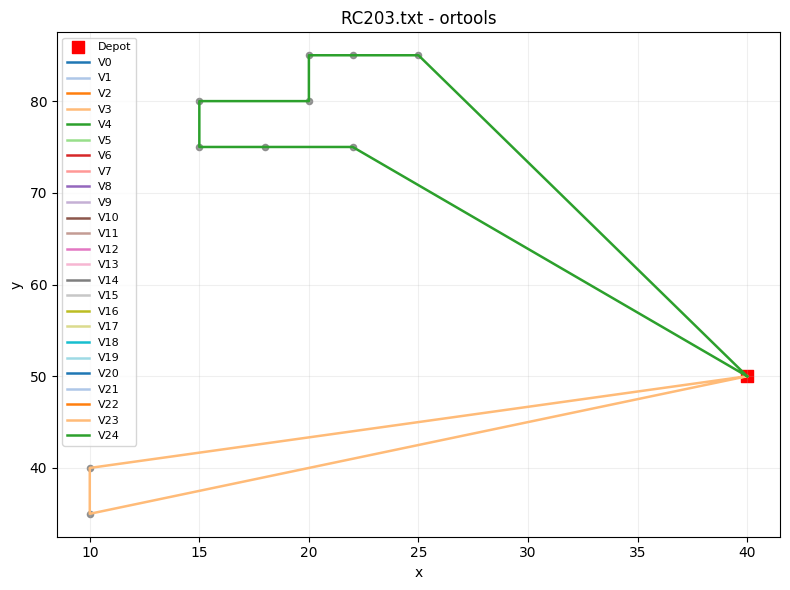

In [6]:
for instance in instances[: min(3, len(instances))]:
    print(f'\n=== {instance.instance_id} ===')
    print('RouteFinder distance:', routefinder_solutions[instance.instance_id].total_distance)
    print('OR-Tools distance:', ortools_solutions[instance.instance_id].total_distance)
    plot_routes(instance, routefinder_solutions[instance.instance_id])
    plot_routes(instance, ortools_solutions[instance.instance_id])


In [7]:
env.generator(1)["time_windows"][0][:10]

tensor([[ 0.0000, 10.1100],
        [ 2.2055,  2.3867],
        [ 5.4691,  5.6661],
        [ 7.0272,  7.2107],
        [ 2.3290,  2.5272],
        [ 7.3363,  7.5268],
        [ 5.6571,  5.8461],
        [ 4.3489,  4.5319],
        [ 5.4822,  5.6634],
        [ 4.6982,  4.8955]])

In [8]:
instance_to_routefinder_td(instances[0], normalize_coords=NORMALIZE_COORDS)["time_windows"][0][:10]

tensor([[ 0.0000, 19.2000],
        [13.4600, 15.8600],
        [ 3.0400,  5.4400],
        [ 9.4200, 11.8200],
        [12.8800, 15.2800],
        [ 1.4600,  3.8600],
        [ 7.7600, 10.1600],
        [ 6.0000,  8.4000],
        [ 7.3400,  9.7400],
        [ 7.4200,  9.8200]])

Averaged cost: 7.061


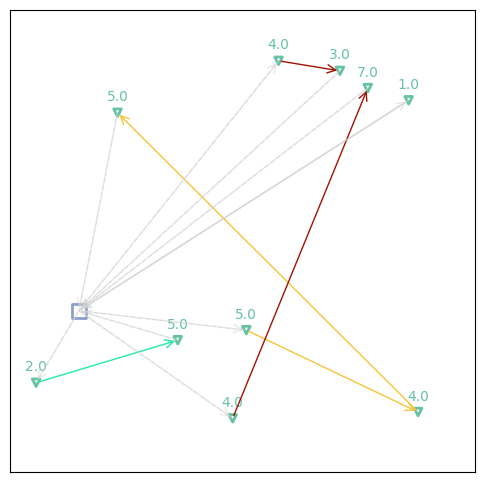

Cost:  8.88955307006836
Problem:  VRPTW


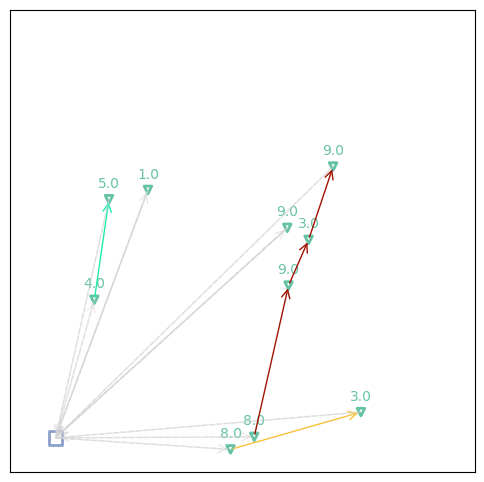

Cost:  7.433147430419922
Problem:  VRPTW


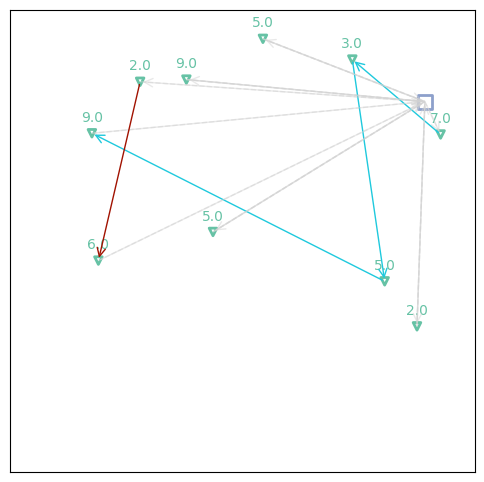

Cost:  8.64122200012207
Problem:  VRPTW
Averaged cost: 5.171
Problem 1 | Cost: 5.287
Variant VRPTW


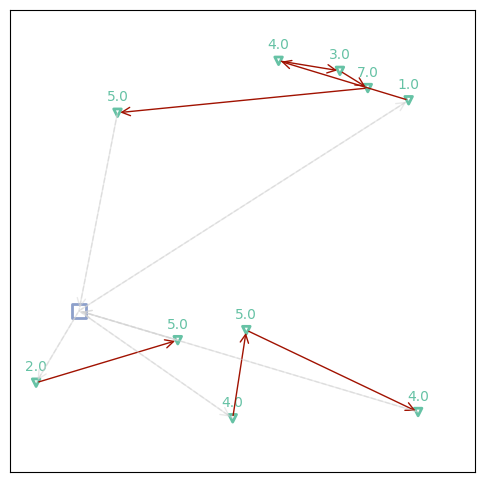

Problem 2 | Cost: 5.542
Variant VRPTW


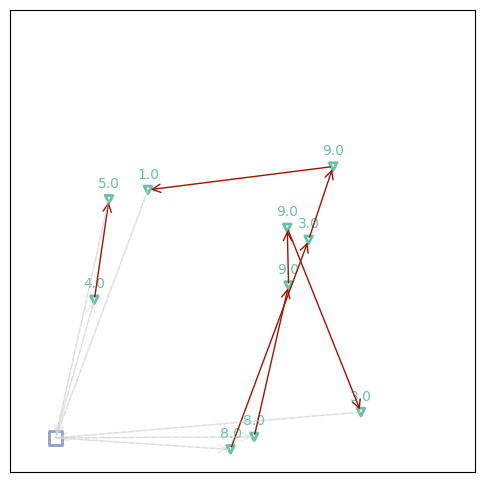

Problem 3 | Cost: 5.566
Variant VRPTW


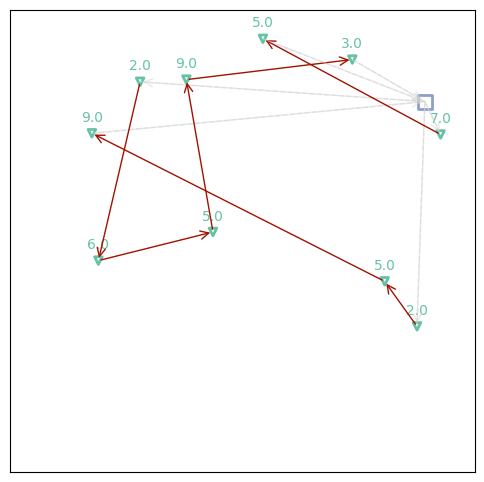

Averaged cost PyVRP: 4.817
Nearest Neighbor gap to HGS-PyVRP: 47.126%
RouteFinder gap to HGS-PyVRP: 7.788%


In [9]:
from routefinder.utils import rollout, greedy_policy, evaluate
td_data = env.generator(50)
#td_test = env.reset(td_data)
# Generate data (mixed variants)
variant_names = env.get_variant_names(td_data)

td_test = env.reset(td_data)

actions = rollout(env, td_test.clone(), greedy_policy)
rewards_nearest_neighbor = env.get_reward(td_test, actions)

print(f"Averaged cost: {-rewards_nearest_neighbor.mean():.3f}")


for idx in [0,1,2]:
    env.render(td_test[idx], actions[idx])
    print("Cost: ", - rewards_nearest_neighbor[idx].item())
    print("Problem: ", variant_names[idx])
    

# Here we use `evaluate` to return the best augmented solution
td_test = td_test.to(device)
model = model.to(device)
out = evaluate(model, td_test.clone())

actions = out["best_aug_actions"]
rewards = env.get_reward(td_test, actions)

print(f"Averaged cost: {-rewards.mean():.3f}")

# Viz
for i in range(3):
    print(f"Problem {i+1} | Cost: {-rewards[i]:.3f}")
    print("Variant", env.get_variant_names(td_test[i]))
    env.render(td_test[i].cpu(), actions[i].cpu())
    
from routefinder.baselines.solve import solve

max_runtime = 3
num_procs = 32

td_test = td_test.cpu()

actions_pyvrp, costs_pyvrp = solve(td_test, max_runtime=max_runtime, num_procs=num_procs, solver="pyvrp")
rewards_pyvrp = env.get_reward(td_test.clone().cpu(), actions_pyvrp)

print(f"Averaged cost PyVRP: {-rewards_pyvrp.mean():.3f}")

from routefinder.baselines.solve import solve

def gap(sol, bks):
    return ((sol - bks) / bks).mean() * 100

print(f"Nearest Neighbor gap to HGS-PyVRP: {gap(rewards_nearest_neighbor.cpu(), rewards_pyvrp.cpu()):.3f}%")
print(f"RouteFinder gap to HGS-PyVRP: {gap(rewards.cpu(), rewards_pyvrp.cpu()):.3f}%")

In [10]:
def summarize_td(td, name):
    tw = td["time_windows"][0].cpu()
    st = td["service_time"][0].cpu()

    starts = tw[:, 0]
    ends = tw[:, 1]
    widths = ends - starts

    print(f"\n{name}")
    print("depot due:", ends[0].item())
    print("start  min/mean/max:", starts.min().item(), starts.mean().item(), starts.max().item())
    print("end    min/mean/max:", ends.min().item(), ends.mean().item(), ends.max().item())
    print("width  min/mean/max:", widths.min().item(), widths.mean().item(), widths.max().item())
    print("service min/mean/max:", st.min().item(), st.mean().item(), st.max().item())

In [11]:
summarize_td(env.generator(1), "train generator")
summarize_td(instance_to_routefinder_td(instances[0], normalize_coords=NORMALIZE_COORDS), "solomon inference")


train generator
depot due: 10.109999656677246
start  min/mean/max: 0.0 3.4188878536224365 8.865884780883789
end    min/mean/max: 1.0088855028152466 4.508968830108643 10.109999656677246
width  min/mean/max: 0.18056559562683105 1.0900814533233643 10.109999656677246
service min/mean/max: 0.0 0.1465526670217514 0.17843660712242126

solomon inference
depot due: 19.200000762939453
start  min/mean/max: 0.0 7.196363925933838 13.460000038146973
end    min/mean/max: 3.859999895095825 11.123636245727539 19.200000762939453
width  min/mean/max: 2.3999996185302734 3.9272725582122803 19.200000762939453
service min/mean/max: 0.0 0.1818181872367859 0.20000000298023224
